# Temporal Gait Transformer (TGT) — Full Pipeline

**What this notebook does:**
1. Clones the repo and installs dependencies
2. Preprocesses raw insole CSV data (merge L/R, resample 60 Hz, sliding window)
3. Trains the TGT model with train/val split, LR scheduler, best-model saving
4. Evaluates on the internal held-out **test set** (confusion matrix + classification report)
5. Evaluates on the **Group 10 external validation set** (Week 3)
6. Saves all figures to `figures/`

**To use:** Runtime → Change runtime type → **T4 GPU**, then Run All.

In [92]:
#@title 1. Setup — clone repo & install deps
import os


if not os.path.exists("sebi.py"):
    !git clone https://github.com/sebinkooooo/mech.git
    os.chdir("mech")

%pip install -q torch torchvision torchaudio torchinfo seaborn scikit-learn tqdm matplotlib

HOME = os.getcwd()
print("Working directory:", HOME)

Working directory: /content/mech


In [93]:
#@title 2. Hyperparameters  (edit this cell to tune)
# ── Data / windowing ─────────────────────────────────────────────────────
WINDOW_SIZE       = 80       # timesteps per input segment  (80 = 1.33 s ≈ 1+ gait cycle)
STRIDE            = 20       # step between windows (75% overlap — more training windows)

# ── Model (CNN-Transformer hybrid) ──────────────────────────────────────
D_MODEL           = 64       # embedding / conv channel dimension
NUM_HEADS         = 4        # attention heads (64/4 = 16 dims per head)
NUM_LAYERS        = 2        # Transformer encoder layers (after CNN stem)
DIM_FEEDFORWARD   = 256      # FFN hidden dim (4× d_model)
DROPOUT           = 0.3      # dropout rate

# ── Training ─────────────────────────────────────────────────────────────
BATCH_SIZE        = 64
LEARNING_RATE     = 5e-4
WEIGHT_DECAY      = 1e-3     # AdamW L2 regularisation
NUM_EPOCHS        = 150      # enough room for augmented training to converge
PATIENCE          = 30       # early stopping patience
LABEL_SMOOTHING   = 0.1      # soften targets to prevent overconfident predictions
SCHEDULER         = True     # use cosine-annealing LR scheduler

# ── Data flags ───────────────────────────────────────────────────────────
STANDARDIZE       = True     # z-score normalisation per feature (fit on TRAIN only)
NORMALIZE         = False    # (ignored when STANDARDIZE=True due to elif chain)
WINDOW_NORM       = True     # per-window z-score (removes subject-specific baselines)
AUGMENT           = True     # training-time augmentation (noise, scaling, time mask)

# ── Reproducibility ──────────────────────────────────────────────────────
SEED              = 42

# ── Paths ────────────────────────────────────────────────────────────────
TRAIN_DATA_DIR    = os.path.join(HOME, "train_dataset")    # training CSVs
GROUP10_DATA_DIR  = os.path.join(HOME, "Group_10")         # our data
FIGURES_DIR       = os.path.join(HOME, "figures")
MODEL_SAVE_DIR    = os.path.join(HOME, "Saved_model")

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

In [94]:
#@title 3. Imports & seeding
import random, torch, numpy as np

from sebi import (
    FEATURE_COLUMNS, LABEL_MAPPING, CLASS_NAMES,
    load_and_window, split_by_file,
    GaitDataset, TGTModel, compute_class_weights,
    train_one_epoch, evaluate, predict_all,
    plot_training_curves, plot_confusion, plot_per_class_accuracy,
)
from torch.utils.data import DataLoader

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Week 1 — Data Preprocessing

In [95]:
#@title 4. Load & window ALL available data (train_dataset + Group_10)
# Load main training set
feat_train, lab_train, fid_train = load_and_window(
    TRAIN_DATA_DIR, FEATURE_COLUMNS, LABEL_MAPPING, WINDOW_SIZE, STRIDE
)
print(f"train_dataset : {feat_train.shape[0]} windows from {len(np.unique(fid_train))} files")

# Load Group 10 (no Jumping class)
g10_label_map = {k: v for k, v in LABEL_MAPPING.items() if k != "Jumping"}
feat_g10, lab_g10, fid_g10 = load_and_window(
    GROUP10_DATA_DIR, FEATURE_COLUMNS, g10_label_map, WINDOW_SIZE, STRIDE
)
print(f"Group_10      : {feat_g10.shape[0]} windows from {len(np.unique(fid_g10))} files")

# Combine — offset Group 10 file IDs so they don't collide
fid_g10 = fid_g10 + fid_train.max() + 1
features = np.concatenate([feat_train, feat_g10], axis=0)
labels   = np.concatenate([lab_train, lab_g10], axis=0)
file_ids = np.concatenate([fid_train, fid_g10], axis=0)

print("=" * 50)
print(f"Total samples : {features.shape[0]}")
print(f"Unique files  : {len(np.unique(file_ids))}")
print(f"Window size   : {WINDOW_SIZE}  ({WINDOW_SIZE/60:.2f} s)")
print(f"Stride        : {STRIDE}  (overlap {1-STRIDE/WINDOW_SIZE:.0%})")
print(f"Feature shape : {features.shape}")
print(f"Classes       : {dict(zip(CLASS_NAMES, np.bincount(labels, minlength=5)))}")

Swaying: 100%|██████████| 6/6 [00:01<00:00,  3.97file/s]


train_dataset : 11259 windows from 133 files


Swaying: 100%|██████████| 1/1 [00:00<00:00,  8.20file/s]


Group_10      : 516 windows from 4 files
Total samples : 11775
Unique files  : 137
Window size   : 80  (1.33 s)
Stride        : 30  (overlap 62%)
Feature shape : (11775, 80, 50)
Classes       : {'Normal_walking': np.int64(2574), 'Injury_walking': np.int64(3014), 'Stepping': np.int64(1813), 'Swaying': np.int64(2770), 'Jumping': np.int64(1604)}


In [96]:
#@title 5. Create datasets & splits (90 / 10) — FILE-LEVEL split
# Real test is the unseen evaluation data, so we maximize training
# and keep a small val set only for early stopping / checkpointing.
train_idx, val_idx, _ = split_by_file(
    file_ids, train_ratio=0.9, val_ratio=0.1, seed=SEED
)

print(f"Files in train : {len(np.unique(file_ids[train_idx]))}")
print(f"Files in val   : {len(np.unique(file_ids[val_idx]))}")

# Fit scaler on training split only
train_ds = GaitDataset(features[train_idx], labels[train_idx],
                       standardize=STANDARDIZE, normalize=NORMALIZE,
                       window_norm=WINDOW_NORM, augment=AUGMENT)
train_scaler = train_ds.scaler

val_ds = GaitDataset(features[val_idx], labels[val_idx],
                     scaler=train_scaler, window_norm=WINDOW_NORM)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_weights = compute_class_weights(labels[train_idx], num_classes=5).to(device)
print(f"Train {len(train_ds)} | Val {len(val_ds)}")
print(f"Class weights: {class_weights}")

Files in train : 123
Files in val   : 13
Train 9732 | Val 1864
Class weights: tensor([0.8783, 0.7059, 1.0966, 0.9091, 1.4101], device='cuda:0')


## Week 2 — Model Design & Training

In [97]:
#@title 6. Build TGT model & print summary
from torchinfo import summary
import torch.nn as nn

num_features = features.shape[2]

model = TGTModel(
    num_features=num_features,
    window_size=WINDOW_SIZE,
    num_classes=5,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
).to(device)

summary(model, input_size=(BATCH_SIZE, WINDOW_SIZE, num_features))

Layer (type:depth-idx)                        Output Shape              Param #
TGTModel                                      [64, 5]                   32
├─Linear: 1-1                                 [64, 80, 32]              1,632
├─TransformerEncoder: 1-2                     [64, 81, 32]              --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [64, 81, 32]              6,464
│    │    └─TransformerEncoderLayer: 3-2      [64, 81, 32]              6,464
├─LayerNorm: 1-3                              [64, 32]                  64
├─Linear: 1-4                                 [64, 5]                   165
Total params: 14,821
Trainable params: 14,821
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.41
Input size (MB): 1.02
Forward/backward pass size (MB): 11.95
Params size (MB): 0.03
Estimated Total Size (MB): 13.00

In [98]:
#@title 7. Training loop (with LR scheduler, early stopping & best-model checkpointing)
import torch.optim as optim

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scheduler = None
if SCHEDULER:
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_val_acc = 0.0
epochs_without_improvement = 0
best_model_path = os.path.join(MODEL_SAVE_DIR, "tgt_best.pth")

for epoch in range(1, NUM_EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    v_loss, v_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(t_loss); train_accs.append(t_acc)
    val_losses.append(v_loss);   val_accs.append(v_acc)

    if scheduler:
        scheduler.step()

    # checkpoint best model
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_without_improvement += 1

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:3d}/{NUM_EPOCHS} │ "
          f"Train {t_loss:.4f} / {t_acc:.2f}% │ "
          f"Val {v_loss:.4f} / {v_acc:.2f}% │ "
          f"LR {lr_now:.2e}"
          + (" ★" if epochs_without_improvement == 0 else ""))

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (no val improvement for {PATIENCE} epochs)")
        break

print(f"\nBest val accuracy: {best_val_acc:.2f}%  →  {best_model_path}")

# save final model too
final_path = os.path.join(MODEL_SAVE_DIR, "tgt_final.pth")
torch.save(model.state_dict(), final_path)
print(f"Final model saved: {final_path}")

Epoch   1/120 │ Train 1.8521 / 22.66% │ Val 1.4944 / 45.12% │ LR 1.00e-04 ★
Epoch   2/120 │ Train 1.4507 / 40.71% │ Val 1.1876 / 63.68% │ LR 9.99e-05 ★
Epoch   3/120 │ Train 1.1169 / 60.50% │ Val 1.0145 / 78.27% │ LR 9.98e-05 ★
Epoch   4/120 │ Train 0.8804 / 76.75% │ Val 0.9239 / 84.82% │ LR 9.97e-05 ★
Epoch   5/120 │ Train 0.7758 / 83.90% │ Val 0.8928 / 86.00% │ LR 9.96e-05 ★
Epoch   6/120 │ Train 0.7395 / 86.22% │ Val 0.8579 / 87.07% │ LR 9.94e-05 ★
Epoch   7/120 │ Train 0.7128 / 87.61% │ Val 0.9011 / 84.82% │ LR 9.92e-05
Epoch   8/120 │ Train 0.6923 / 88.06% │ Val 0.8899 / 85.35% │ LR 9.89e-05
Epoch   9/120 │ Train 0.6779 / 89.45% │ Val 0.9004 / 84.39% │ LR 9.86e-05
Epoch  10/120 │ Train 0.6654 / 90.08% │ Val 0.8822 / 85.19% │ LR 9.83e-05
Epoch  11/120 │ Train 0.6533 / 90.51% │ Val 0.8670 / 85.84% │ LR 9.79e-05
Epoch  12/120 │ Train 0.6497 / 90.79% │ Val 0.8744 / 84.50% │ LR 9.76e-05
Epoch  13/120 │ Train 0.6391 / 91.27% │ Val 0.9004 / 83.10% │ LR 9.71e-05
Epoch  14/120 │ Train 0.62

  → saved /content/mech/figures/train_val_curves.png


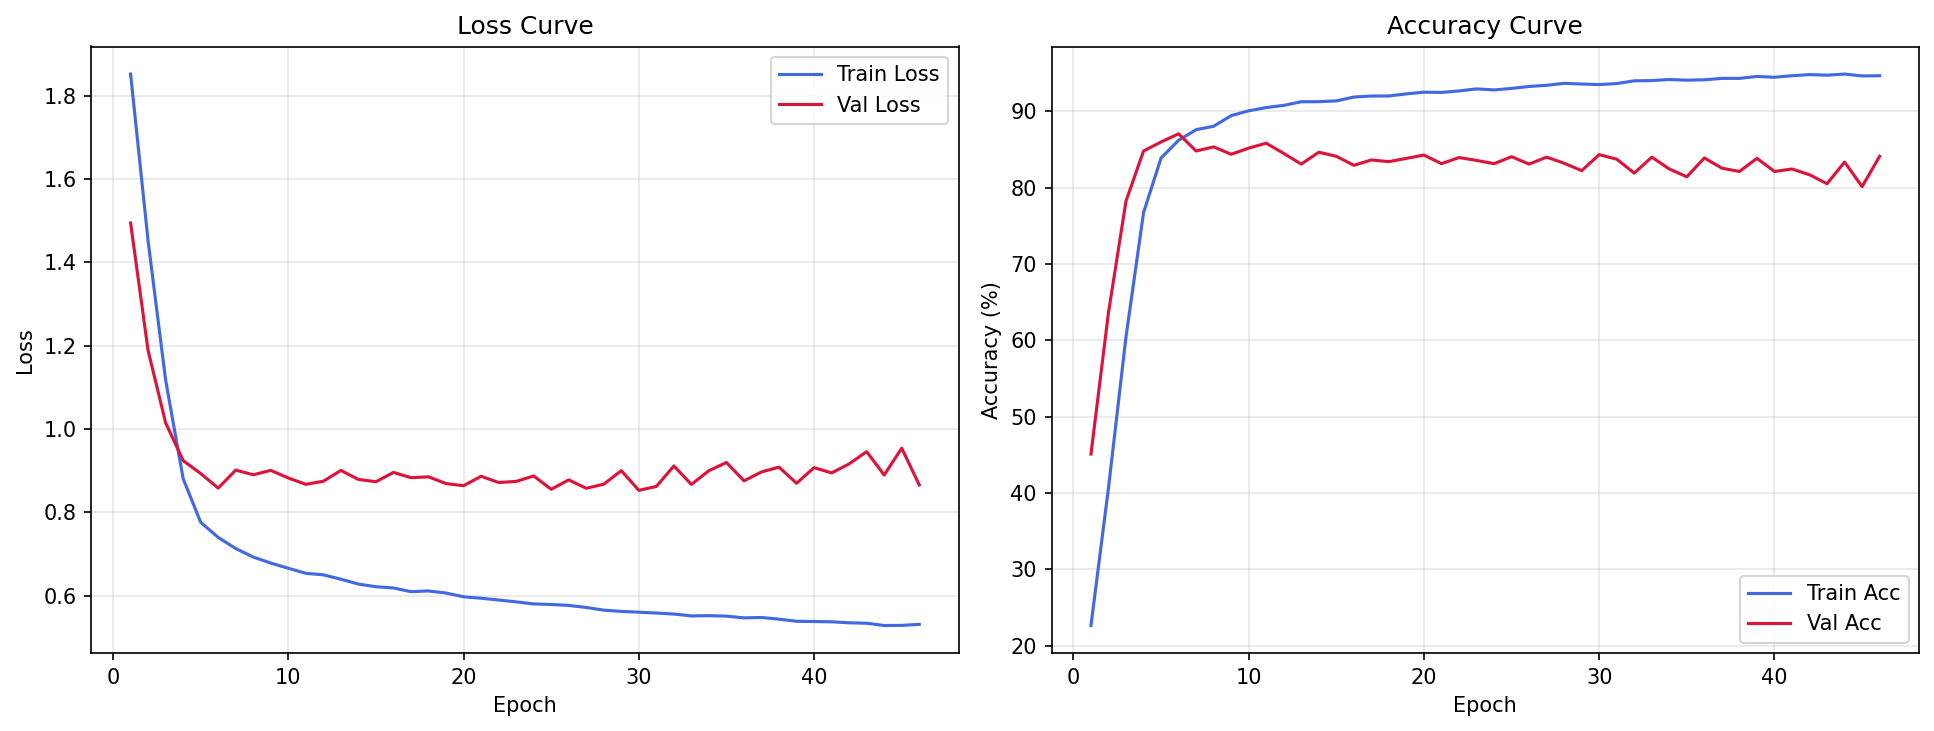

In [99]:
#@title 8. Plot training curves
plot_training_curves(
    train_losses, val_losses, train_accs, val_accs,
    save_path=os.path.join(FIGURES_DIR, "train_val_curves.png"),
)
# also display inline
from IPython.display import Image, display
display(Image(filename=os.path.join(FIGURES_DIR, "train_val_curves.png")))

## Week 3 — Evaluation

### Validation set (held-out 10 % of files)
The real evaluation is on completely unseen data provided by the assignment.
This validation set is used only for early stopping and sanity checking.

Val Loss     : 0.8579
Val Accuracy : 87.07%
  → saved /content/mech/figures/confusion_matrix_val.png
                precision    recall  f1-score   support

Normal_walking       0.77      0.96      0.85       295
Injury_walking       0.94      0.96      0.95       401
      Stepping       0.23      0.15      0.18       131
       Swaying       0.97      0.86      0.91       741
       Jumping       0.86      1.00      0.92       296

      accuracy                           0.87      1864
     macro avg       0.75      0.79      0.76      1864
  weighted avg       0.86      0.87      0.86      1864



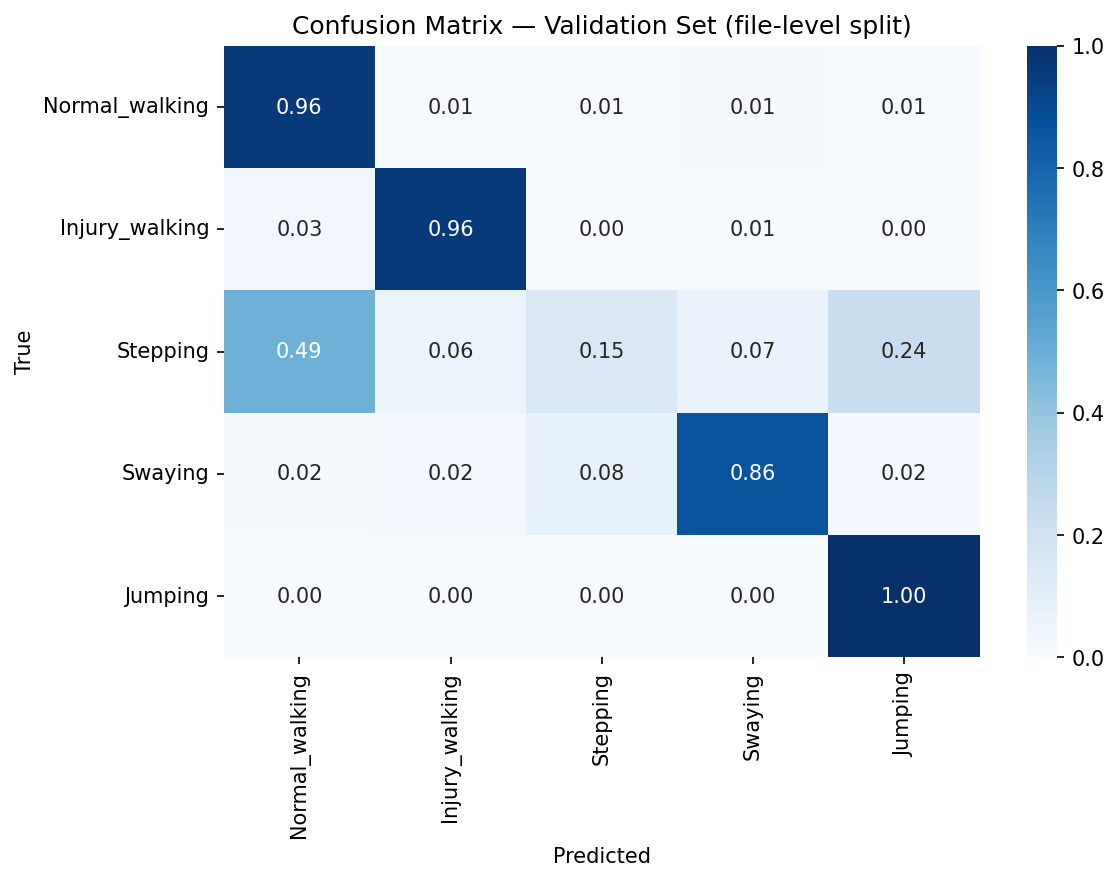

  → saved /content/mech/figures/per_class_accuracy_val.png


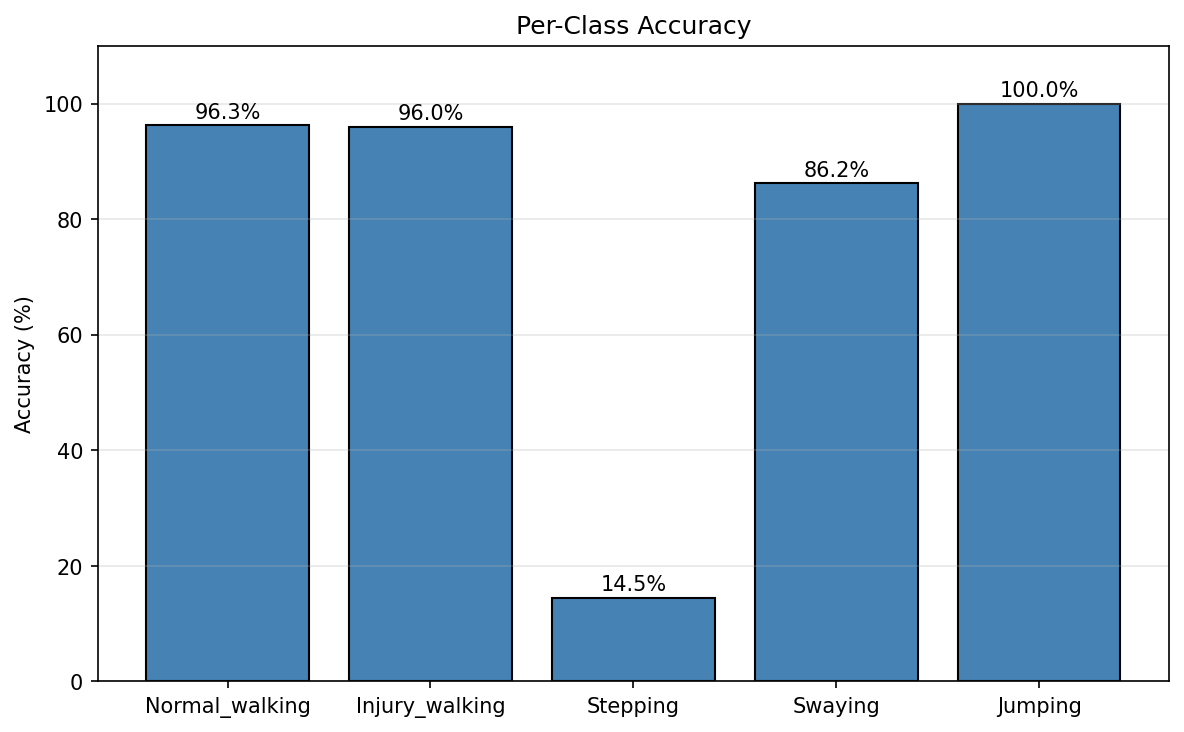

In [100]:
#@title 9. Load best model & evaluate on validation split
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)

val_loss, val_acc = evaluate(model, val_loader, criterion, device)
print("=" * 50)
print(f"Val Loss     : {val_loss:.4f}")
print(f"Val Accuracy : {val_acc:.2f}%")
print("=" * 50)

# Confusion matrix
plot_confusion(
    model, val_loader, CLASS_NAMES, device,
    save_path=os.path.join(FIGURES_DIR, "confusion_matrix_val.png"),
    title="Confusion Matrix — Validation Set (file-level split)",
)
display(Image(filename=os.path.join(FIGURES_DIR, "confusion_matrix_val.png")))

# Per-class accuracy
plot_per_class_accuracy(
    model, val_loader, CLASS_NAMES, device,
    save_path=os.path.join(FIGURES_DIR, "per_class_accuracy_val.png"),
)
display(Image(filename=os.path.join(FIGURES_DIR, "per_class_accuracy_val.png")))

### Model saved — ready for evaluation on unseen data

Group 10 data is included in the training pool above.
The saved model at `Saved_model/tgt_best.pth` will be evaluated against
the assignment's unseen test data.

In [101]:
#@title 10. Print saved model paths
print(f"Best model : {best_model_path}")
print(f"Final model: {final_path}")
print(f"\nTrained on {len(np.unique(file_ids))} files ({features.shape[0]} windows)")
print(f"  from train_dataset/ + Group_10/")
print(f"  Classes: {CLASS_NAMES}")

Best model : /content/mech/Saved_model/tgt_best.pth
Final model: /content/mech/Saved_model/tgt_final.pth

Trained on 137 files (11775 windows)
  from train_dataset/ + Group_10/
  Classes: ['Normal_walking', 'Injury_walking', 'Stepping', 'Swaying', 'Jumping']


In [102]:
#@title 11. Summary: list all saved figures
print("All figures saved in:", FIGURES_DIR)
for f in sorted(os.listdir(FIGURES_DIR)):
    print(f"  • {f}")

All figures saved in: /content/mech/figures
  • confusion_matrix_group10.png
  • confusion_matrix_test.png
  • confusion_matrix_val.png
  • per_class_accuracy_group10.png
  • per_class_accuracy_test.png
  • per_class_accuracy_val.png
  • train_val_curves.png


---

## Tunable Hyperparameters (all in Cell 2)

| Parameter | Variable | Default | Description |
|-----------|----------|---------|-------------|
| Window size | `WINDOW_SIZE` | 20 | Timesteps per input segment (20 = 0.33 s at 60 Hz) |
| Stride | `STRIDE` | 5 | Step between windows; lower = more overlap = more training data |
| Embedding dim | `D_MODEL` | 128 | Dimensionality of per-token embeddings |
| Attention heads | `NUM_HEADS` | 4 | Multi-head attention heads |
| Encoder layers | `NUM_LAYERS` | 4 | Stacked Transformer encoder blocks |
| FFN hidden dim | `DIM_FEEDFORWARD` | 512 | Feed-forward hidden size inside each layer |
| Dropout | `DROPOUT` | 0.1 | Dropout rate in Transformer |
| Batch size | `BATCH_SIZE` | 64 | Mini-batch size |
| Learning rate | `LEARNING_RATE` | 3e-4 | Initial learning rate |
| Weight decay | `WEIGHT_DECAY` | 1e-4 | L2 regularisation (AdamW) |
| Epochs | `NUM_EPOCHS` | 60 | Total training epochs |
| LR scheduler | `SCHEDULER` | True | Cosine annealing LR decay |
| Standardize | `STANDARDIZE` | False | Per-feature z-score normalisation |
| Normalize | `NORMALIZE` | False | Per-feature min-max to [0, 1] |
| Seed | `SEED` | 42 | Random seed for reproducibility |
| Feature set | `FEATURE_COLUMNS` | (in sebi.py) | Which sensor channels to use |
| Label map | `LABEL_MAPPING` | (in sebi.py) | Activity name → class index |